注意力评分函数（attention scoring function）或简称评分函数（scoring function）用于建模查询和键之间的关系。
其输出结果会通过softmax函数生成与键对应的值的概率分布，即注意力权重。
注意力汇聚的输出是基于这些注意力权重的值的加权和。

给定查询 $\mathbf{q} \in \mathbb{R}^q$ 和 $m$ 个“键－值”对 $(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)$，其中 $\mathbf{k}_i \in \mathbb{R}^k$，$\mathbf{v}_i \in \mathbb{R}^v$。

注意力汇聚函数 $f$ 表示为值的加权和：

$$f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)) = \sum_{i=1}^m \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i \in \mathbb{R}^v$$

其中注意力权重 $\alpha(\mathbf{q}, \mathbf{k}_i)$ 是通过注意力评分函数 $a$ 和 softmax 运算得到的：

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^m \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}.$$

不同的注意力评分函数 $a$ 会导致不同的注意力汇聚操作。

In [1]:
import math
import torch
from torch import nn


掩蔽 softmax 操作（masked softmax operation）

主要用于在注意力汇聚中筛选出有意义的值。
在某些情况下，例如处理填充了无意义特殊词元的文本序列时，并非所有的值都应被纳入注意力汇聚。
通过指定一个有效序列长度，掩蔽 softmax 可以在计算 softmax 时过滤掉超出有效长度的位置，并将这些位置的值置为0，从而只关注有意义的词元。

In [2]:
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape

        # Prepare valid_lens to be a 1D tensor of shape (N,)
        # where N is the total number of sequences to mask (e.g., batch_size * num_heads)
        if valid_lens.dim() == 1:
            # If valid_lens is (batch_size,) and X is (batch_size, num_heads, seq_len),
            # repeat each valid_len for each head.
            valid_lens_flat = torch.repeat_interleave(valid_lens, shape[1])
        else: # valid_lens.dim() == 2 (e.g., (batch_size, num_heads))
            # Flatten to (batch_size * num_heads,)
            valid_lens_flat = valid_lens.reshape(-1)

        # Flatten X along all but the last dimension to (N, sequence_length)
        X_flat = X.reshape(-1, shape[-1])
        maxlen = X_flat.size(1) # This is the sequence_length

        # Create a tensor of indices [0, 1, ..., maxlen-1]
        mask_indices = torch.arange(maxlen, dtype=X.dtype, device=X.device)

        # Create the boolean mask: (N, maxlen)
        # True where index < valid_length (elements to keep)
        # False where index >= valid_length (elements to mask)
        mask = mask_indices[None, :] < valid_lens_flat[:, None]

        # Apply the mask: set elements where mask is False (index >= valid_len) to a very large negative value
        # This makes their softmax probability effectively zero.
        X_masked_flat = X_flat.masked_fill(~mask, -1e6)

        # Reshape back to original shape and apply softmax
        return nn.functional.softmax(X_masked_flat.reshape(shape), dim=-1)

加性注意力

当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。给定查询 $\mathbf{q} \in \mathbb{R}^q$ 和键 $\mathbf{k} \in \mathbb{R}^k$，加性注意力（additive attention）的评分函数为：

$$a(\mathbf q, \mathbf k) = \mathbf w_v^\top \text{tanh}(\mathbf W_q\mathbf q + \mathbf W_k \mathbf k) \in \mathbb{R},$$

其中可学习的参数是 $\mathbf W_q\in\mathbb R^{h\times q}$、$\mathbf W_k\in\mathbb R^{h\times k}$ 和 $\mathbf w_v\in\mathbb R^{h}$。该方法将查询和键连结起来后输入到一个多层感知机（MLP）中，该感知机包含一个隐藏层，其隐藏单元数是一个超参数 $h$。这里使用 $\tanh$ 作为激活函数，并且禁用偏置项。

In [3]:
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，queries的形状是(batch_size，查询的序列长度，1，num_hiddens)
        # 而keys的形状是(batch_size，“键－值”对的序列长度，num_hiddens，1)
        # 两个张量进行求和，都利用了广播机制
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状是(batch_size，查询的序列长度，“键－值”对的序列长度)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # 返回注意力权重乘以值的和，其形状是(batch_size，查询的序列长度，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)

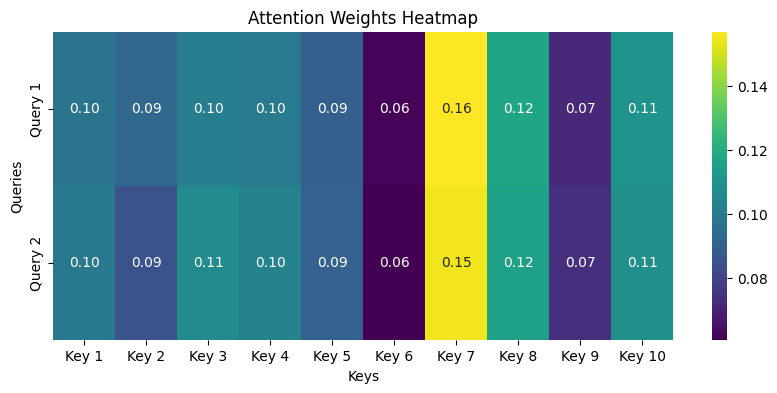

In [4]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming AdditiveAttention class is defined in the notebook.
# If not, please ensure the cell defining AdditiveAttention is executed first.

# Create a dummy instance of AdditiveAttention
# key_size, query_size, num_hiddens, dropout
attention = AdditiveAttention(key_size=30, query_size=20, num_hiddens=8, dropout=0.1)

# Create dummy inputs for the forward pass
batch_size = 1
query_seq_len = 2 # Number of queries
key_seq_len = 10  # Number of keys
value_size = 5    # Value dimension (arbitrary)

queries = torch.randn(batch_size, query_seq_len, 20) # (batch_size, query_seq_len, query_size)
keys = torch.randn(batch_size, key_seq_len, 30)     # (batch_size, key_seq_len, key_size)
values = torch.randn(batch_size, key_seq_len, value_size) # (batch_size, key_seq_len, value_size)
valid_lens = torch.tensor([key_seq_len]) # Example valid length (full length here)

# Perform a forward pass to get attention weights
output = attention(queries, keys, values, valid_lens)

# Extract the attention weights
# The attention_weights tensor from AdditiveAttention should have shape (batch_size, query_seq_len, key_seq_len)
attention_weights_to_plot = attention.attention_weights.squeeze(0).detach().numpy()

# Create the heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(
    attention_weights_to_plot,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    xticklabels=[f'Key {i+1}' for i in range(key_seq_len)],
    yticklabels=[f'Query {i+1}' for i in range(query_seq_len)]
)
plt.xlabel('Keys')
plt.ylabel('Queries')
plt.title('Attention Weights Heatmap')
plt.show()